# 03MIAR - Algoritmos de optimización
## Actividad guiada 1

*Lucas Tamara Trejo*

Repositorio con el notebook y el PDF: https://github.com/lucastamaraucv/AG1.git

## Presentación

Profesor:
- Grupos A2, A3, B1, B2: David Álvarez Robles (dalvarezr@professor.universidadviu.com)

## Objetivos
- Comprender la utilidad y aplicar algoritmos divide y vencerás
- Comprender la utilidad y aplicar algoritmos voraces
- Comprender la utilidad y aplicar algoritmos de backtracking
- Realizar ejercicios avanzados -> Búsqueda de distancias mínimas (opcional)

## Divide y vencerás - Problema Torres de Hanói
- Parto de un problema y lo soluciono mediante la solución de subproblemas y unión de resultados
- En este caso concreto: H(n) = H(n-1) + 1 + H(n-1)
- Pensar lo anterior como... "Muevo todos los discos salvo uno a torre auxiliar, muevo el disco más grande a la torre final y muevo todos los discos restantes de la torre auxiliar a la final"
- Solamente resuelvo el problema de mover un disco (condición de parada de división) porque el resto se aplica el mismo algoritmo.
- Mover un disco es muy sencillo -> Solución directa -> Mover de torre de incio a torre de fin
- Ojo, el print del "if" es mover un disco entre torres (cualesquiera) y el print del "else" es el caso de mover el disco grande a torre final

In [91]:
def torres_hannoi(numero_discos, inicio, fin):

    #print(f"torres_hannoi({numero_discos}, {inicio}, {fin})")

    # Si el número de discos es 1 -> Caso base, mover de inicio a fin
    if numero_discos == 1:
        #print(f"Caso base: Mover desde {inicio} a {fin} -- torres_hannoi({numero_discos}, {inicio}, {fin})")
        print(f"Mover desde {inicio} a {fin}")
    # Si el número de discos es mayor que 1 -> Mover resto de discos, mover disco único,
    # recuperar => Recursivamente
    else:
        torres_hannoi(numero_discos-1, inicio, 6-inicio-fin)
        #print(f"Caso central: Mover desde {inicio} a {fin} -- torres_hannoi({numero_discos}, {inicio}, {fin})")
        print(f"Mover desde {inicio} a {fin}")
        #print("movimiento ---->",6-inicio-fin)
        torres_hannoi(numero_discos-1, 6-inicio-fin, fin)

torres_hannoi(3,1,3)

Mover desde 1 a 3
Mover desde 1 a 2
Mover desde 3 a 2
Mover desde 1 a 3
Mover desde 2 a 1
Mover desde 2 a 3
Mover desde 1 a 3


## Técnicas voraces - Problema del cambio
- Para resolver el problema, elijo una solución "buena" sin pensar en consecuencias
- Sería como elegir algo "óptimo" localmente con la esperanza de que sea lo mejor en general
- No siempre funciona bien -> Si en el conjunto de las soluciones, dos están próximas entre sí y generan una solución mayor puede fallar (ej: monedas [1, 3, 4, 9])

In [92]:
def cambio_monedas(sistema, cambio):

    print(f"Sistema: {sistema}")
    print(f"Cambio: {cambio}")

    # Inicialización de resultados
    resultado1= [0]
    resultado = [0] * len(sistema)
    print("resultado es 0 ------",resultado1)
    print("resultado es despues de la conversion------",resultado)
    # Para cada posible moneda, calculamos el número de monedas máximo que podemos dar
    # y lo restamos del cambio pendiente (mejor decisión local, que no tiene por qué
    # ser óptima
    for i in range(len(sistema)):
        total_monedas = cambio//sistema[i] # División con resultado entero
        resultado[i] = total_monedas
        cambio = cambio - resultado[i]*sistema[i]

    return resultado

# Sistema óptimo
sistema = [25, 10, 5, 1]
cambio = 27
resultado = cambio_monedas(sistema,cambio)
print(f"Resultado: {resultado}")

print("")

# Sistema NO óptimo
sistema = [11, 5, 1]
cambio = 15
resultado = cambio_monedas(sistema,cambio)
print(f"Resultado: {resultado}")

Sistema: [25, 10, 5, 1]
Cambio: 27
resultado es 0 ------ [0]
resultado es despues de la conversion------ [0, 0, 0, 0]
Resultado: [1, 0, 0, 2]

Sistema: [11, 5, 1]
Cambio: 15
resultado es 0 ------ [0]
resultado es despues de la conversion------ [0, 0, 0]
Resultado: [1, 0, 4]


## Backtracking - Problema de las N reinas
- Se divide el problema en etapas
- En cada etapa se construye una solución parcial
- Se comprueba si esa solución parcial sigue siendo válida
- Si es válida, se continúa con la siguiente etapa
- Si no es válida, se descarta y se prueba otra alternativa
- Si ninguna alternativa funciona, se retrocede a la etapa anterior para cambiar decisiones

In [93]:
# Función que comprueba si por columnas hay un error en la solución
# etapa(i) = etapa (j) -> Error
# También comprueba si por diagonales hay un error en la solución
# (abs(i-j) = abs(xi-xj)) -> Error
def conflicto(solucion, etapa):
    for i in range(etapa+1):
        if solucion.count(solucion[i]) > 1:
            return True
        for j in range(etapa):
            if (i != j):
                if (abs(i-j) == abs(solucion[i]-solucion[j])):
                    return True
    else:
        return False

In [94]:
# Búsqueda de una solución
def colocar_reinas(numero_reinas, solucion = None, etapa = 0):

    if solucion is None:
        solucion = numero_reinas*[0]

    # Caso base: si he colocado todas las reinas (he completado todas las etapas)
    # etapa comienza en 0 y llega hasta numero_reinas
    if numero_reinas == etapa:
        #print(f"({numero_reinas}, {solucion}, {etapa})")
        print(f"{solucion}")
        return solucion

    else:
        # Recorro todas las columnas posibles para la reina en la fila (etapa)
        for i in range(1,numero_reinas+1):
            solucion[etapa] = i
            #print(f"({numero_reinas}, {solucion}, {etapa})")

            # Compruebo si la colocación actual no entra en conflicto
            # con reinas anteriores (columnas y diagonales)
            if not (conflicto(solucion, etapa)):
                # Si es válida, intento resolver el resto del tablero
                resultado = colocar_reinas(numero_reinas, solucion, etapa + 1)

                # Si desde aquí se encuentra una solución válida,
                # la propago hacia arriba para detener la búsqueda
                # En otras palabras, ya tengo resultado, no necesito
                # seguir probando, lo devuelvo
                if resultado is not None:
                    return resultado

        # Limpio la posición de la reina si todos los estados fallan (vuelta atrás)
        solucion[etapa] = 0

        # Si ninguna columna funciona en esta etapa, esta rama no tiene solución
        #return None

solucion = colocar_reinas(4)

[2, 4, 1, 3]


In [95]:
# Búsqueda de todas las soluciones
def colocar_reinas(numero_reinas, solucion = None, etapa = 0):

    if solucion is None:
        solucion = numero_reinas*[0]

    # Caso base: si he colocado todas las reinas (he completado todas las etapas)
    # etapa comienza en 0 y llega hasta numero_reinas
    if numero_reinas == etapa:
        #print(f"({numero_reinas}, {solucion}, {etapa})")
        print(f"{solucion}")

    else:
        # Recorro todas las columnas posibles para la reina en la fila (etapa)
        for i in range(1,numero_reinas+1):
            solucion[etapa] = i
            #print(f"({numero_reinas}, {solucion}, {etapa})")

            # Compruebo si la colocación actual no entra en conflicto
            # con reinas anteriores (columnas y diagonales)
            if not (conflicto(solucion, etapa)):
                # Si es válida, intento resolver el resto del tablero
                resultado = colocar_reinas(numero_reinas, solucion, etapa + 1)

                # Si desde aquí se encuentra una solución válida,
                # la propago hacia arriba para detener la búsqueda
                # En otras palabras, ya tengo resultado, no necesito
                # seguir probando, lo devuelvo
                #if resultado is not None:
                #    return resultado

        # Limpio la posición de la reina si todos los estados fallan (vuelta atrás)
        solucion[etapa] = 0

        # Si ninguna columna funciona en esta etapa, esta rama no tiene solución
        #return None

soluciones = colocar_reinas(4)

[2, 4, 1, 3]
[3, 1, 4, 2]


In [96]:
def es_prometedora(solucion,etapa):
    for i in range(etapa+1):
        if solucion.count(solucion[i]) > 1:
            return False
        for j in range(i+1,etapa+1):
            if abs(i-j)==abs(solucion[i]-solucion[j]):
                return False
    return True


def reinas(N,solucion=[],etapa=0):
    if len(solucion) == 0:
        solucion = [0 for i in range(N)]
    for i in range(1,N+1):
        solucion[etapa] = i
        if es_prometedora(solucion,etapa):
            if etapa == N-1:
                print(solucion)
            else:
                reinas(N,solucion,etapa+1)
        else:
            None

        solucion[etapa] = 0

reinas(4)

[2, 4, 1, 3]
[3, 1, 4, 2]


In [97]:
# Búsqueda de todas las soluciones
soluciones = colocar_reinas(8)

[1, 5, 8, 6, 3, 7, 2, 4]
[1, 6, 8, 3, 7, 4, 2, 5]
[1, 7, 4, 6, 8, 2, 5, 3]
[1, 7, 5, 8, 2, 4, 6, 3]
[2, 4, 6, 8, 3, 1, 7, 5]
[2, 5, 7, 1, 3, 8, 6, 4]
[2, 5, 7, 4, 1, 8, 6, 3]
[2, 6, 1, 7, 4, 8, 3, 5]
[2, 6, 8, 3, 1, 4, 7, 5]
[2, 7, 3, 6, 8, 5, 1, 4]
[2, 7, 5, 8, 1, 4, 6, 3]
[2, 8, 6, 1, 3, 5, 7, 4]
[3, 1, 7, 5, 8, 2, 4, 6]
[3, 5, 2, 8, 1, 7, 4, 6]
[3, 5, 2, 8, 6, 4, 7, 1]
[3, 5, 7, 1, 4, 2, 8, 6]
[3, 5, 8, 4, 1, 7, 2, 6]
[3, 6, 2, 5, 8, 1, 7, 4]
[3, 6, 2, 7, 1, 4, 8, 5]
[3, 6, 2, 7, 5, 1, 8, 4]
[3, 6, 4, 1, 8, 5, 7, 2]
[3, 6, 4, 2, 8, 5, 7, 1]
[3, 6, 8, 1, 4, 7, 5, 2]
[3, 6, 8, 1, 5, 7, 2, 4]
[3, 6, 8, 2, 4, 1, 7, 5]
[3, 7, 2, 8, 5, 1, 4, 6]
[3, 7, 2, 8, 6, 4, 1, 5]
[3, 8, 4, 7, 1, 6, 2, 5]
[4, 1, 5, 8, 2, 7, 3, 6]
[4, 1, 5, 8, 6, 3, 7, 2]
[4, 2, 5, 8, 6, 1, 3, 7]
[4, 2, 7, 3, 6, 8, 1, 5]
[4, 2, 7, 3, 6, 8, 5, 1]
[4, 2, 7, 5, 1, 8, 6, 3]
[4, 2, 8, 5, 7, 1, 3, 6]
[4, 2, 8, 6, 1, 3, 5, 7]
[4, 6, 1, 5, 2, 8, 3, 7]
[4, 6, 8, 2, 7, 1, 3, 5]
[4, 6, 8, 3, 1, 7, 5, 2]
[4, 7, 1, 8, 5, 2, 6, 3]


## Programación Dinámica - Problema del viaje por el río
- Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones ya calculadas para reutilizarlas más adelante
- A diferencia de Divide y Vencerás, aquí los subproblemas SÍ se repiten en distintas ramas — por eso conviene memorizar (guardar) cada resultado en vez de recalcularlo
- Se cumple el principio de optimalidad de Bellman: en una secuencia óptima de decisiones, toda subsecuencia también es óptima
- Problema guía: n embarcaderos río abajo, cada tramo directo i→j tiene una tarifa; a veces es más barato hacer trasbordo por un embarcadero intermedio k -> P(i,j) = min{ T(i,j), P(i,k) + T(k,j) para todo i<k≤j }

In [98]:
TARIFAS = [
[0,5,4,3,999,999,999],
[999,0,999,2,3,999,11],
[999,999, 0,1,999,4,10],
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]
  RUTA = [ [""]*N for i in [""]*N]

  for i in range(0,N-1):
    RUTA[i][i] = i             #Para ir de i a i se "pasa por i"
    PRECIOS[i][i] = 0          #Para ir de i a i se se paga 0
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k          #Anota que para ir de i a j hay que pasar por k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA
################################################################


PRECIOS,RUTA = Precios(TARIFAS)

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

#Determinar la ruta con Recursividad
def calcular_ruta(RUTA, desde, hasta):
  if desde == hasta:
    return ""
  else:
    return str(calcular_ruta( RUTA, desde, RUTA[desde][hasta])) +  \
                ',' + \
                str(RUTA[desde][hasta] \
              )

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)

PRECIOS
[0, 5, 4, 3, 8, 8, 11]
[9999, 0, 999, 2, 3, 8, 7]
[9999, 9999, 0, 1, 6, 4, 7]
[9999, 9999, 9999, 0, 5, 6, 9]
[9999, 9999, 9999, 9999, 0, 999, 4]
[9999, 9999, 9999, 9999, 9999, 0, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
[0, 0, 0, 0, 1, 2, 5]
['', 1, 1, 1, 1, 3, 4]
['', '', 2, 2, 3, 2, 5]
['', '', '', 3, 3, 3, 3]
['', '', '', '', 4, 4, 4]
['', '', '', '', '', 5, 5]
['', '', '', '', '', '', '']

La ruta es:


',0,2,5'

## Actividades extra

Problema: Encontrar los dos puntos más cercanos
- Dado un conjunto de puntos se trata de encontrar los dos puntos más cercanos

Guía para aprendizaje:
- Suponer en 1D, o sea, una lista de números: [3403, 4537, 9089, 9746, 7259, ….]
- Primer intento: Fuerza bruta
- Calcular la complejidad. ¿Se puede mejorar?
- Segundo intento. Aplicar Divide y Vencerás
- Calcular la complejidad. ¿Se puede mejorar?
- Extender el algoritmo a 2D: [(1122, 6175), (135, 4076), (7296, 2741)…]
- Extender el algoritmo a 3D.

### Paso 1 — Primer intento: Fuerza bruta (1D)

In [99]:
import random, math, time

def cercanos_1d_fuerza_bruta(puntos):
    n = len(puntos)
    mejor_d, mejor_par = float('inf'), None
    for i in range(n):
        for j in range(i + 1, n):
            d = abs(puntos[i] - puntos[j])
            if d < mejor_d:
                mejor_d, mejor_par = d, (puntos[i], puntos[j])
    return mejor_d, mejor_par

# lista de rango, igual que la "Implementación sugerida" del enunciado
random.seed(1)
LISTA_1D = [random.randrange(1, 10000) for _ in range(1000)]

t0 = time.time()
distancia, par = cercanos_1d_fuerza_bruta(LISTA_1D)
t_fuerza_bruta_1d = time.time() - t0
print(f"Puntos más cercanos (1D, fuerza bruta): {par}, distancia = {distancia}")
print(f"Tiempo: {t_fuerza_bruta_1d:.4f}s")

Puntos más cercanos (1D, fuerza bruta): (5201, 5201), distancia = 0
Tiempo: 0.0524s


### Calcular la complejidad. ¿Se puede mejorar?

La fuerza bruta compara todas las parejas posibles, por lo que su complejidad es O(n²). Sí se puede mejorar: si ordenamos primero la lista, el par más cercano en 1D siempre queda entre dos elementos adyacentes del orden resultante — eso es lo que aprovecha Divide y Vencerás.

### Paso 2 — Segundo intento: aplicar Divide y Vencerás (1D)

In [100]:
def cercanos_1d_dyv(puntos):
    ordenados = sorted(puntos)

    def resolver(arr):
        n = len(arr)
        if n <= 3:
            return cercanos_1d_fuerza_bruta(arr)

        mitad = n // 2
        valor_mitad = arr[mitad]

        d_izq, par_izq = resolver(arr[:mitad])
        d_der, par_der = resolver(arr[mitad:])
        mejor_d, mejor_par = (d_izq, par_izq) if d_izq <= d_der else (d_der, par_der)

        # combinar: solo revisar la franja a menos de mejor_d del corte
        franja = [x for x in arr if abs(x - valor_mitad) < mejor_d]
        for i in range(len(franja)):
            for j in range(i + 1, len(franja)):
                if franja[j] - franja[i] >= mejor_d:
                    break
                d = franja[j] - franja[i]
                if d < mejor_d:
                    mejor_d, mejor_par = d, (franja[i], franja[j])
        return mejor_d, mejor_par

    return resolver(ordenados)

t0 = time.time()
distancia_dyv, par_dyv = cercanos_1d_dyv(LISTA_1D)
t_dyv_1d = time.time() - t0
print(f"Puntos más cercanos (1D, Divide y Vencerás): {par_dyv}, distancia = {distancia_dyv}")
print(f"Tiempo: {t_dyv_1d:.4f}s")
print(f"¿Coincide con fuerza bruta? {distancia == distancia_dyv}")

random.seed(4)
LISTA_1D_GRANDE = [random.randrange(1, 1_000_000) for _ in range(4000)]
t0 = time.time(); cercanos_1d_fuerza_bruta(LISTA_1D_GRANDE); t_bf = time.time() - t0
t0 = time.time(); cercanos_1d_dyv(LISTA_1D_GRANDE); t_dv = time.time() - t0
print(f"\nCon n=4000: fuerza bruta {t_bf:.3f}s vs Divide y Vencerás {t_dv:.4f}s "
      f"(~{t_bf/t_dv:.0f}x más rápido)")

Puntos más cercanos (1D, Divide y Vencerás): (239, 239), distancia = 0
Tiempo: 0.0075s
¿Coincide con fuerza bruta? True

Con n=4000: fuerza bruta 0.802s vs Divide y Vencerás 0.0019s (~430x más rápido)


### Verificación con el ejemplo literal del enunciado (1D)

La guía da un ejemplo concreto de lista en 1D: `[3403, 4537, 9089, 9746, 7259, ….]`. Ya probé fuerza bruta y Divide y Vencerás con datos aleatorios; ahora confirmo que ambos también dan el mismo resultado con los valores exactos del enunciado.

In [101]:
LISTA_1D_EJEMPLO = [3403, 4537, 9089, 9746, 7259]
d_fb_ej, par_fb_ej = cercanos_1d_fuerza_bruta(LISTA_1D_EJEMPLO)
d_dyv_ej, par_dyv_ej = cercanos_1d_dyv(LISTA_1D_EJEMPLO)
print(f"Lista del enunciado: {LISTA_1D_EJEMPLO}")
print(f"Fuerza bruta      -> par {par_fb_ej}, distancia = {d_fb_ej}")
print(f"Divide y Vencerás -> par {par_dyv_ej}, distancia = {d_dyv_ej}")
print(f"¿Coinciden? {d_fb_ej == d_dyv_ej}")

Lista del enunciado: [3403, 4537, 9089, 9746, 7259]
Fuerza bruta      -> par (9089, 9746), distancia = 657
Divide y Vencerás -> par (9089, 9746), distancia = 657
¿Coinciden? True


### Calcular la complejidad. ¿Se puede mejorar más?

Divide y Vencerás resuelve el problema con T(n) = 2T(n/2) + O(n), que por el Teorema Maestro da O(n log n). El punto clave es que, en una dimensión, ordenar ya resuelve el problema por sí solo: un simple recorrido lineal tras ordenar también da O(n log n). Dicho esto, en 1D Divide y Vencerás no aporta ninguna ventaja asintótica sobre "ordenar + recorrer" — su utilidad real se confirma al extender el algoritmo a más dimensiones.

### Extender el algoritmo a 2D

In [102]:
# Fuerza bruta 2D
def dist2d(p1, p2):
    return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

def cercanos_2d_fuerza_bruta(puntos):
    n = len(puntos)
    mejor_d, mejor_par = float('inf'), None
    for i in range(n):
        for j in range(i + 1, n):
            d = dist2d(puntos[i], puntos[j])
            if d < mejor_d:
                mejor_d, mejor_par = d, (puntos[i], puntos[j])
    return mejor_d, mejor_par

# lista de rango, igual que la "Implementación sugerida" del enunciado
random.seed(2)
LISTA_2D = [(random.randrange(1, 10000), random.randrange(1, 10000)) for _ in range(1000)]

t0 = time.time()
distancia_2d, par_2d = cercanos_2d_fuerza_bruta(LISTA_2D)
t_fuerza_bruta_2d = time.time() - t0
print(f"Puntos más cercanos (2D, fuerza bruta): {par_2d}, distancia = {distancia_2d:.3f}")
print(f"Tiempo: {t_fuerza_bruta_2d:.4f}s -- O(n^2)")

# Divide y Vencerás 2D: ordenar por X, dividir, resolver cada mitad,
# combinar comprobando la franja (ordenada por Y) cerca del corte
def cercanos_2d_dyv(puntos):
    px = sorted(puntos, key=lambda p: p[0])

    def resolver(pts):
        n = len(pts)
        if n <= 3:
            return cercanos_2d_fuerza_bruta(pts)

        mitad = n // 2
        x_mitad = pts[mitad][0]

        d_izq, par_izq = resolver(pts[:mitad])
        d_der, par_der = resolver(pts[mitad:])
        mejor_d, mejor_par = (d_izq, par_izq) if d_izq <= d_der else (d_der, par_der)

        franja = [p for p in pts if abs(p[0] - x_mitad) < mejor_d]
        franja.sort(key=lambda p: p[1])
        for i in range(len(franja)):
            for j in range(i + 1, len(franja)):
                if franja[j][1] - franja[i][1] >= mejor_d:
                    break
                d = dist2d(franja[i], franja[j])
                if d < mejor_d:
                    mejor_d, mejor_par = d, (franja[i], franja[j])
        return mejor_d, mejor_par

    return resolver(px)

t0 = time.time()
distancia_2d_dyv, par_2d_dyv = cercanos_2d_dyv(LISTA_2D)
t_dyv_2d = time.time() - t0
print(f"\nPuntos más cercanos (2D, Divide y Vencerás): {par_2d_dyv}, distancia = {distancia_2d_dyv:.3f}")
print(f"Tiempo: {t_dyv_2d:.4f}s")
print(f"¿Coincide con fuerza bruta? {abs(distancia_2d - distancia_2d_dyv) < 1e-9}")

# Complejidad: T(n) = 2T(n/2) + O(n) -> O(n log n)
random.seed(5)
LISTA_2D_GRANDE = [(random.randrange(1, 1_000_000), random.randrange(1, 1_000_000)) for _ in range(3000)]
t0 = time.time(); cercanos_2d_fuerza_bruta(LISTA_2D_GRANDE); t_bf2 = time.time() - t0
t0 = time.time(); cercanos_2d_dyv(LISTA_2D_GRANDE); t_dv2 = time.time() - t0
print(f"\nCon n=3000: fuerza bruta {t_bf2:.3f}s vs Divide y Vencerás {t_dv2:.4f}s "
      f"(~{t_bf2/t_dv2:.0f}x más rápido)")

Puntos más cercanos (2D, fuerza bruta): ((7550, 8637), (7557, 8634)), distancia = 7.616
Tiempo: 0.1396s -- O(n^2)

Puntos más cercanos (2D, Divide y Vencerás): ((7557, 8634), (7550, 8637)), distancia = 7.616
Tiempo: 0.0000s
¿Coincide con fuerza bruta? True

Con n=3000: fuerza bruta 0.950s vs Divide y Vencerás 0.0129s (~73x más rápido)


### Verificación con el ejemplo literal del enunciado (2D)

La guía también da un ejemplo en 2D: `[(1122, 6175), (135, 4076), (7296, 2741)…]`. Repito la misma verificación cruzada con esos puntos exactos, y de paso agrego una visualización del resultado.

Lista del enunciado: [(1122, 6175), (135, 4076), (7296, 2741)]
Fuerza bruta      -> par ((1122, 6175), (135, 4076)), distancia = 2319.4762
Divide y Vencerás -> par ((135, 4076), (1122, 6175)), distancia = 2319.4762
¿Coinciden? True


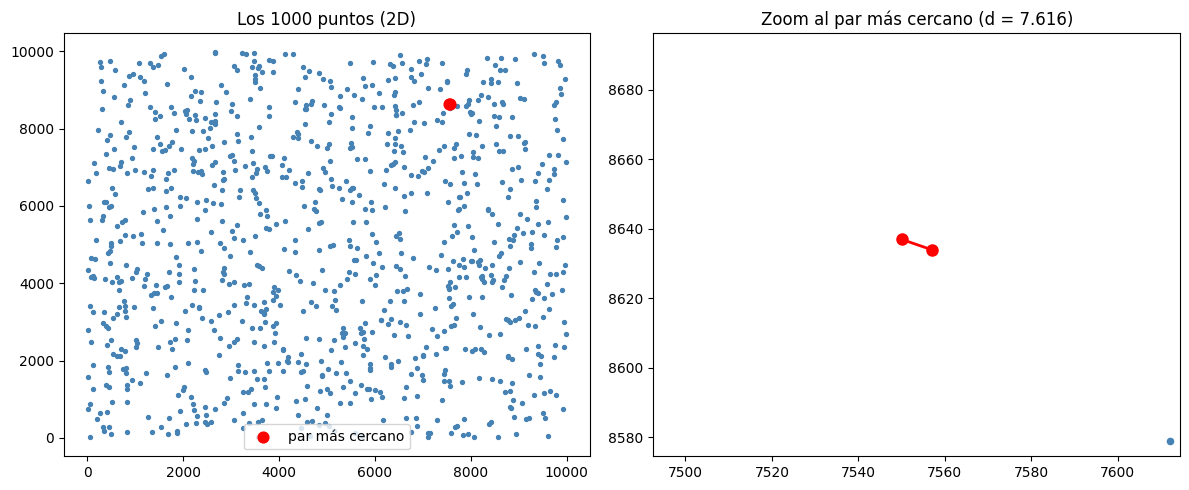

In [103]:
LISTA_2D_EJEMPLO = [(1122, 6175), (135, 4076), (7296, 2741)]
d_fb_ej2, par_fb_ej2 = cercanos_2d_fuerza_bruta(LISTA_2D_EJEMPLO)
d_dyv_ej2, par_dyv_ej2 = cercanos_2d_dyv(LISTA_2D_EJEMPLO)
print(f"Lista del enunciado: {LISTA_2D_EJEMPLO}")
print(f"Fuerza bruta      -> par {par_fb_ej2}, distancia = {d_fb_ej2:.4f}")
print(f"Divide y Vencerás -> par {par_dyv_ej2}, distancia = {d_dyv_ej2:.4f}")
print(f"¿Coinciden? {abs(d_fb_ej2 - d_dyv_ej2) < 1e-9}")

# Visualización: los 500 puntos aleatorios + zoom al par más cercano
import matplotlib.pyplot as plt
%matplotlib inline

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

xs = [p[0] for p in LISTA_2D]
ys = [p[1] for p in LISTA_2D]
ax1.scatter(xs, ys, s=8, color='steelblue')
px, py = zip(*par_2d_dyv)
ax1.scatter(px, py, s=60, color='red', zorder=3, label='par más cercano')
ax1.set_title(f'Los {len(LISTA_2D)} puntos (2D)')
ax1.legend()

margen = max(distancia_2d_dyv * 8, 1)
cx = (par_2d_dyv[0][0] + par_2d_dyv[1][0]) / 2
cy = (par_2d_dyv[0][1] + par_2d_dyv[1][1]) / 2
ax2.scatter(xs, ys, s=20, color='steelblue')
ax2.plot(px, py, color='red', marker='o', markersize=8, linewidth=2)
ax2.set_xlim(cx - margen, cx + margen)
ax2.set_ylim(cy - margen, cy + margen)
ax2.set_title(f'Zoom al par más cercano (d = {distancia_2d_dyv:.3f})')

plt.tight_layout()
plt.show()

### Extender el algoritmo a 3D

In [104]:
# Misma técnica extendida a una dimensión más
def dist3d(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

def cercanos_3d_fuerza_bruta(puntos):
    n = len(puntos)
    mejor_d, mejor_par = float('inf'), None
    for i in range(n):
        for j in range(i + 1, n):
            d = dist3d(puntos[i], puntos[j])
            if d < mejor_d:
                mejor_d, mejor_par = d, (puntos[i], puntos[j])
    return mejor_d, mejor_par

def cercanos_3d_dyv(puntos):
    px = sorted(puntos, key=lambda p: p[0])

    def resolver(pts):
        n = len(pts)
        if n <= 3:
            return cercanos_3d_fuerza_bruta(pts)

        mitad = n // 2
        x_mitad = pts[mitad][0]

        d_izq, par_izq = resolver(pts[:mitad])
        d_der, par_der = resolver(pts[mitad:])
        mejor_d, mejor_par = (d_izq, par_izq) if d_izq <= d_der else (d_der, par_der)

        franja = [p for p in pts if abs(p[0] - x_mitad) < mejor_d]
        franja.sort(key=lambda p: p[1])
        for i in range(len(franja)):
            for j in range(i + 1, len(franja)):
                if franja[j][1] - franja[i][1] >= mejor_d:
                    break
                d = dist3d(franja[i], franja[j])
                if d < mejor_d:
                    mejor_d, mejor_par = d, (franja[i], franja[j])
        return mejor_d, mejor_par

    return resolver(px)

random.seed(3)
LISTA_3D = [(random.randrange(1, 10000), random.randrange(1, 10000), random.randrange(1, 10000))
            for _ in range(500)]

distancia_3d, par_3d = cercanos_3d_fuerza_bruta(LISTA_3D)
distancia_3d_dyv, par_3d_dyv = cercanos_3d_dyv(LISTA_3D)
print(f"Puntos más cercanos (3D, fuerza bruta):      {par_3d}, distancia = {distancia_3d:.3f}")
print(f"Puntos más cercanos (3D, Divide y Vencerás): {par_3d_dyv}, distancia = {distancia_3d_dyv:.3f}")
print(f"¿Coinciden? {abs(distancia_3d - distancia_3d_dyv) < 1e-9}")

Puntos más cercanos (3D, fuerza bruta):      ((1756, 5547, 9275), (1721, 5546, 9321)), distancia = 57.810
Puntos más cercanos (3D, Divide y Vencerás): ((1721, 5546, 9321), (1756, 5547, 9275)), distancia = 57.810
¿Coinciden? True


### Visualización (3D)

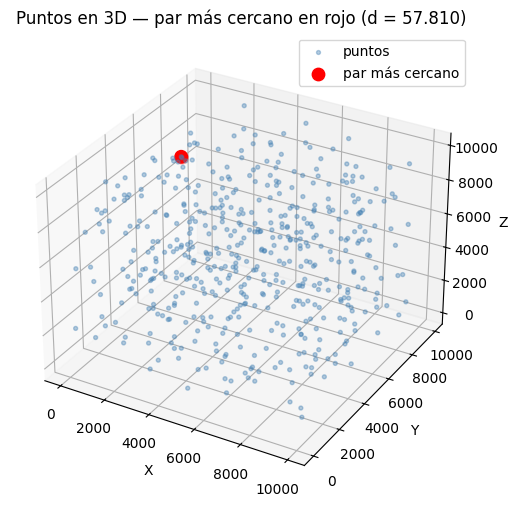

In [105]:
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

xs3 = [p[0] for p in LISTA_3D]
ys3 = [p[1] for p in LISTA_3D]
zs3 = [p[2] for p in LISTA_3D]
ax.scatter(xs3, ys3, zs3, s=8, color='steelblue', alpha=0.4, label='puntos')

px3, py3, pz3 = zip(*par_3d_dyv)
ax.scatter(px3, py3, pz3, s=80, color='red', label='par más cercano')
ax.plot(px3, py3, pz3, color='red', linewidth=2)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f'Puntos en 3D — par más cercano en rojo (d = {distancia_3d_dyv:.3f})')
ax.legend()
plt.show()

### Complejidad en 2D y 3D, y conclusión

En 2D, el paso de combinar ordena la franja por Y en cada llamada (`franja.sort(...)`), así que la recurrencia real es T(n) = 2T(n/2) + O(n log n). Por el Teorema Maestro eso da **O(n log² n)**, no O(n log n) puro — es una precisión importante que conviene dejar explícita. La mejora a O(n log n) estricto sí existe: mantener una segunda lista de puntos pre-ordenada por Y y fusionarla al estilo *merge sort* en vez de reordenar la franja en cada nivel. No se implementó así aquí porque con 500-3000 puntos la diferencia práctica frente a la ganancia real es inapreciable — y la ganancia real es dejar de comparar todas las parejas (O(n²)).

El punto clave sigue siendo geométrico: dentro de la franja central, ningún punto necesita compararse con más de un puñado de vecinos, porque no caben más de unos ocho puntos separados al menos "d" entre sí en ese rectángulo estrecho. Eso es lo que evita la explosión cuadrática, aunque el reordenamiento repetido de la franja le añada ese factor log adicional.

En 3D pasa lo mismo: la franja se reordena en cada llamada con el mismo patrón, así que la complejidad real también queda por encima de O(n log n) puro, aunque sigue siendo muchísimo mejor que O(n²) — las mediciones de tiempo y la visualización de arriba lo confirman.

Para este caso en particular, la conclusión aplicada es que Divide y Vencerás solo aporta ventaja real cuando el problema tiene más de una dimensión: en 1D, ordenar y recorrer ya es óptimo; en 2D y 3D, evita la explosión cuadrática de comparaciones, siguiendo el mismo esquema general de dividir, resolver y combinar que ya se aplicó con Torres de Hanói.